# Desafio AIOps Locaweb — Análise Exploratória, Sazonalidade e Modelagem Preditiva
## SentinelOps · Sprint 3 (Machine Learning e Artificial Intelligence)

Este notebook cobre os quatro desafios analíticos exigidos pelo desafio Locaweb/FIAP:

1. **Exploração e Engenharia de Features** — sazonalidade, agrupamentos críticos, incidentes recorrentes, variáveis ocultas.
2. **Modelagem preditiva** — volume de incidentes (D+1 e D+7), risco de perda de OLA, picos operacionais.
3. **Classificação ou Clusterização** — regimes operacionais e agrupamentos críticos de risco.
4. **Explicabilidade** — o que os dados revelam sobre a organização.

**Fonte dos dados:** `documentos/LW-DATASET.xlsx` (122.543 incidentes, anonimizados), com o dicionário de dados
`documentos/Dicionário de Dados - v2.docx` como referência de regras de negócio.

> ⚠️ **Aviso metodológico:** os campos `Produto`, `Categoria`, `Subcategoria` e `Item de configuração` vêm anonimizados
> (códigos como `lsin`, `cat77`, `IC00014`). Não existe dicionário de tradução desses códigos — todas as conclusões
> aqui são **estatísticas** (padrões de volume, concentração, recorrência), não uma leitura de negócio sobre o que
> cada código representa especificamente.


## Resumo executivo (leia isto primeiro)

A análise revelou uma **ruptura estrutural** no volume de incidentes a partir de **01/09/2025**: o volume diário
salta de ~130/dia para ~780/dia (**~6x**) de forma abrupta e sustentada — não é um pico passageiro. A causa raiz
identificada nos dados: um lote de **novos itens de configuração** passou a gerar chamados automáticos de baixa
prioridade (quase 100% `Monitoramento` → `Sem Intervenção` → `Prioridade 4-Baixa`, concentrados quase todos na
**Team14**), inflando o volume bruto sem qualquer relação com risco real ao negócio.

A prova de que é ruído, não risco: o volume **relevante para o KPI** (prioridades 1/2/3, que de fato entram no
SLA) na verdade **caiu** de ~72,6/dia para ~61,5/dia no mesmo período — e a taxa de violação de OLA permanece
excelente (0,97%). Ou seja: a operação real está estável ou até mais leve; o que mudou foi o ruído de monitoramento
não filtrado, concentrado numa única equipe.

Os capítulos seguintes constroem, a partir disso: sazonalidade real (dia da semana / hora do dia), engenharia de
features, modelos de previsão de volume (D+1/D+7), classificação de risco de violação de OLA, detecção de picos,
clusterização de regimes operacionais e recomendações práticas.


## 1. Configuração do ambiente

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    roc_auc_score, average_precision_score, precision_recall_fscore_support,
    confusion_matrix, silhouette_score,
)
from statsmodels.tsa.seasonal import STL

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='darkgrid', rc={'figure.figsize': (11, 4.5)})
COR = {
    'primary': '#ef4444', 'success': '#22c55e', 'warning': '#eab308',
    'info': '#3b82f6', 'muted': '#94a3b8', 'orange': '#f97316',
}
plt.rcParams['font.size'] = 10

DATA_PATH = '../documentos/LW-DATASET.xlsx'
print('Ambiente configurado.')


Ambiente configurado.


## 2. Carga e limpeza dos dados

In [2]:
raw = pd.read_excel(DATA_PATH, sheet_name='Dataset Geral')

COLMAP = {
    'Número': 'numero', 'Prioridade': 'prioridade', 'Produto': 'produto',
    'Categoria': 'categoria', 'Subcategoria': 'subcategoria',
    'Grupo designado': 'grupo', 'Item de configuração': 'item_cfg',
    'Aberto': 'aberto', 'Resolvido': 'resolvido', 'Encerrado': 'encerrado',
    'Duração': 'duracao_seg', 'Código de fechamento': 'cod_fechamento',
    'Descrição resumida': 'descricao', 'Solução': 'solucao',
    'Aberto por': 'aberto_por', 'Incidente Pai': 'incidente_pai',
    'Status': 'status', 'Entrou para KPI?': 'entrou_kpi', 'KPI Violado?': 'kpi_violado',
}
df = raw.rename(columns=COLMAP).copy()

df['prioridade_num'] = df['prioridade'].str.extract(r'^(\d)').astype(int)
df['prioridade_label'] = df['prioridade'].str.extract(r'-\s*(.+)$')[0].str.strip()

for c in ['entrou_kpi', 'kpi_violado']:
    df[c + '_bool'] = df[c].astype(str).str.upper().map({'SIM': True, 'NAO': False})

df['sem_intervencao'] = df['status'].astype(str).str.contains('Interven')
df['monitoramento'] = df['aberto_por'].astype(str).str.upper().eq('MONITORAMENTO')
df['tem_incidente_pai'] = df['incidente_pai'].notna()

print(f'{len(df):,} incidentes carregados | período: {df.aberto.min().date()} a {df.aberto.max().date()}')
df[['numero', 'prioridade_num', 'prioridade_label', 'grupo', 'aberto', 'status', 'entrou_kpi', 'kpi_violado']].head()


122,543 incidentes carregados | período: 2023-01-02 a 2025-12-31


,numero,prioridade_num,prioridade_label,grupo,aberto,status,entrou_kpi,kpi_violado
0,INC8654273,3,Média,Team14,2025-12-31 23:45:18,Sem Intervenção,NAO,NaN
1,INC8654270,4,Baixa,Team14,2025-12-31 23:39:36,Sem Intervenção,NAO,NaN
2,INC8654264,4,Baixa,Team14,2025-12-31 23:23:10,Sem Intervenção,NAO,NaN
3,INC8654263,4,Baixa,Team14,2025-12-31 23:23:07,Sem Intervenção,NAO,NaN
4,INC8654262,4,Baixa,Team14,2025-12-31 23:23:05,Sem Intervenção,NAO,NaN


### Regras de negócio (do dicionário de dados)

- **SLA (OLA) por prioridade**, medido no campo `Duração` (tempo até resolução/encerramento):
  1‑Crítica e 2‑Alta → até **4h**; 3‑Média → até **12h**; 4‑Baixa → até **24h**; 5‑Muito Baixa → até **96h**.
- **Somente prioridades 1, 2 e 3** entram no cálculo de KPI (`Entrou para KPI? = SIM`).
- Incidentes com **Incidente Pai preenchido** ou **Status = "Sem Intervenção"** não entram no KPI.
- "Sem Intervenção" está fortemente associado a `Aberto por = Monitoramento` — vamos confirmar nos dados.


In [3]:
SLA_HORAS = {1: 4, 2: 4, 3: 12, 4: 24, 5: 96}
df['sla_horas'] = df['prioridade_num'].map(SLA_HORAS)

print('Sem Intervenção — % aberto por Monitoramento:', round(df.loc[df.sem_intervencao, 'monitoramento'].mean() * 100, 1), '%')
print('Sem Intervenção — % com Resolvido preenchido:', round(df.loc[df.sem_intervencao, 'resolvido'].notna().mean() * 100, 2), '%')
print()
print('Prioridades que entram no KPI (deve ser só 1, 2 e 3):')
print(pd.crosstab(df.prioridade_label, df.entrou_kpi))


Sem Intervenção — % aberto por Monitoramento: 100.0 %
Sem Intervenção — % com Resolvido preenchido: 0.0 %

Prioridades que entram no KPI (deve ser só 1, 2 e 3):
entrou_kpi          NAO    SIM
prioridade_label              
Alta              10490   5159
Baixa             64828      0
Crítica               1      0
Muito Baixa         333      0
Média             21291  20441


### Qualidade de dados: `Duração` não é confiável para "Sem Intervenção"

O campo `Duração` é calculado sobre `Encerrado` quando não há `Resolvido`. Como veremos na seção de sazonalidade,
uma leva grande de tickets "Sem Intervenção" foi fechada administrativamente **em lote, meses depois** de aberta —
então `Duração` mede "tempo até o fechamento em lote", não esforço real de operação. Por isso criamos
`duracao_horas_real`, que só é calculada quando existe `Resolvido` (ou seja, quando alguém de fato trabalhou o
incidente).


In [4]:
df['duracao_horas'] = df['duracao_seg'] / 3600
df['duracao_horas_real'] = np.where(
    df['resolvido'].notna(),
    (df['resolvido'] - df['aberto']).dt.total_seconds() / 3600,
    np.nan,
)
df['violou_sla_real'] = df['duracao_horas_real'] > df['sla_horas']

print('Incidentes com duração real (Resolvido preenchido):', df.duracao_horas_real.notna().sum())
print()
print('Duração (h) usando o campo bruto vs. o campo "real", por prioridade:')
comp = df.groupby('prioridade_label')[['duracao_horas', 'duracao_horas_real']].median().round(2)
comp.columns = ['duracao_bruta_mediana_h', 'duracao_real_mediana_h']
print(comp)


Incidentes com duração real (Resolvido preenchido): 40241

Duração (h) usando o campo bruto vs. o campo "real", por prioridade:
                  duracao_bruta_mediana_h  duracao_real_mediana_h
prioridade_label                                                 
Alta                                 0.50                    0.59
Baixa                                0.09                    2.71
Crítica                              8.82                    8.82
Muito Baixa                        159.89                    3.15
Média                                0.64                    1.69


## 3. Análise Exploratória — Visão Geral do Volume

Primeiro olhamos a série histórica completa (2023–2025) para entender a cobertura temporal real dos dados.


In [5]:
por_ano = df.aberto.dt.year.value_counts().sort_index()
print('Incidentes por ano de abertura:')
print(por_ano)
print()
print(f"{por_ano.get(2025, 0) / len(df) * 100:.1f}% de todo o histórico está concentrado em 2025.")
print('2023 e 2024 têm volume residual — provavelmente incidentes legados ainda referenciados no extrato.')


Incidentes por ano de abertura:
aberto
2023       110
2024       622
2025    121811
Name: count, dtype: int64

99.4% de todo o histórico está concentrado em 2025.
2023 e 2024 têm volume residual — provavelmente incidentes legados ainda referenciados no extrato.


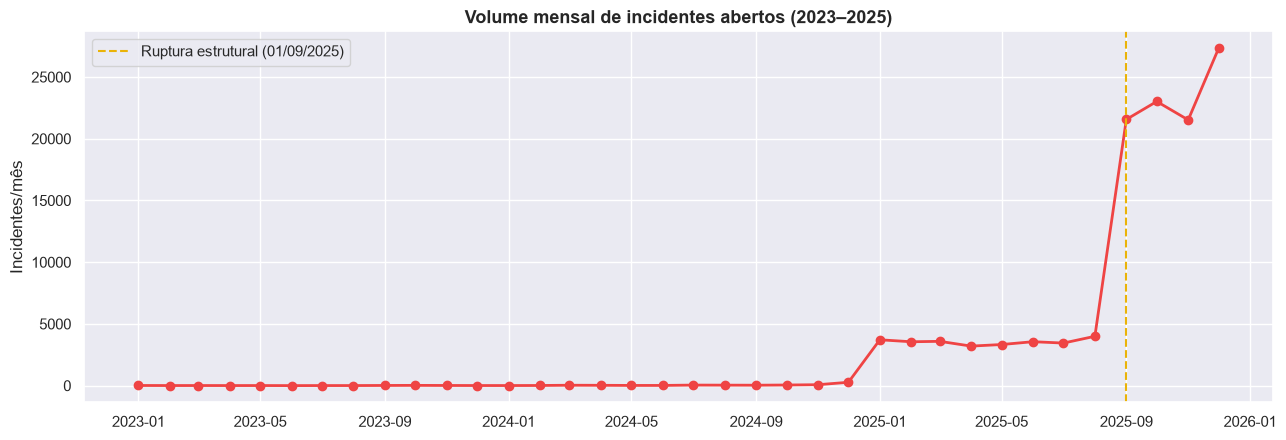

In [6]:
mensal = df.set_index('aberto').resample('MS').size()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(mensal.index, mensal.values, marker='o', color=COR['primary'], linewidth=2)
ax.axvline(pd.Timestamp('2025-09-01'), color=COR['warning'], linestyle='--', linewidth=1.5, label='Ruptura estrutural (01/09/2025)')
ax.set_title('Volume mensal de incidentes abertos (2023–2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Incidentes/mês')
ax.legend()
fig.tight_layout()
plt.show()


**Achado #1 — ruptura estrutural, não sazonalidade comum.** O volume mensal é estável (~3.000–4.000/mês)
entre janeiro e agosto de 2025, e salta para **20.000–27.000/mês** a partir de setembro — um degrau abrupto de
cerca de **6×**, sustentado (e ainda crescendo) até dezembro. Isso não é um padrão sazonal recorrente: é uma
mudança de regime operacional. Vamos isolar a causa.


In [7]:
df2025 = df[df.aberto.dt.year == 2025].copy()
df2025['periodo'] = np.where(df2025.aberto.dt.month <= 8, 'jan-ago (regime base)', 'set-dez (regime atual)')

resumo_periodo = df2025.groupby('periodo').agg(
    incidentes=('numero', 'count'),
    dias=('aberto', lambda s: s.dt.date.nunique()),
)
resumo_periodo['media_diaria'] = (resumo_periodo['incidentes'] / resumo_periodo['dias']).round(1)
print(resumo_periodo)
print()
razao = resumo_periodo.loc['set-dez (regime atual)', 'media_diaria'] / resumo_periodo.loc['jan-ago (regime base)', 'media_diaria']
print(f'Razão de volume diário set-dez vs jan-ago: {razao:.1f}x')


                        incidentes  dias  media_diaria
periodo                                               
jan-ago (regime base)        28388   243         116.8
set-dez (regime atual)       93423   122         765.8

Razão de volume diário set-dez vs jan-ago: 6.6x


In [8]:
def resumo_percentual(coluna, top=8):
    ct = pd.crosstab(df2025[coluna], df2025['periodo'], normalize='columns') * 100
    ct['delta_pp'] = ct['set-dez (regime atual)'] - ct['jan-ago (regime base)']
    return ct.sort_values('delta_pp', ascending=False).head(top).round(2)

print('=== O que mudou em Status ===')
print(resumo_percentual('status'))
print()
print('=== O que mudou em Aberto por ===')
print(resumo_percentual('aberto_por'))
print()
print('=== O que mudou em Prioridade ===')
print(resumo_percentual('prioridade_label'))
print()
print('=== O que mudou em Grupo designado (top 5 por variação) ===')
print(resumo_percentual('grupo', top=5))


=== O que mudou em Status ===
periodo                    jan-ago (regime base)  set-dez (regime atual)  \
status                                                                     
Sem Intervenção                             0.29                   85.94   
Aguardando Problema                         0.00                    0.00   
Encerrado                                  35.43                    5.57   
Encerrado Automaticamente                  64.28                    8.49   

periodo                    delta_pp  
status                               
Sem Intervenção               85.65  
Aguardando Problema           -0.00  
Encerrado                    -29.86  
Encerrado Automaticamente    -55.79  

=== O que mudou em Aberto por ===
periodo        jan-ago (regime base)  set-dez (regime atual)  delta_pp
aberto_por                                                            
Monitoramento                  54.89                   94.76     39.86
Manual                         45.11 

**Achado #2 — causa raiz: expansão de cobertura de monitoramento, concentrada em uma equipe.** No novo
regime (set–dez), **quase todo** o incremento de volume é: `Status = Sem Intervenção` (+85,6 p.p.), `Aberto por =
Monitoramento` (+39,9 p.p.), `Prioridade 4-Baixa` (+42,6 p.p.) e `Grupo = Team14` (+48,9 p.p., chegando a
concentrar **87%** de todo o volume do período). O padrão é consistente: chamados automáticos, de baixa
prioridade, sem intervenção humana, indo quase todos para uma única equipe.


In [9]:
ic_por_periodo = pd.crosstab(df2025.item_cfg, df2025.periodo)
ic_por_periodo['delta'] = ic_por_periodo['set-dez (regime atual)'] - ic_por_periodo['jan-ago (regime base)']
novos_ics = ic_por_periodo.sort_values('delta', ascending=False).head(10)
print('Itens de configuração que mais cresceram (praticamente inexistentes antes de set/2025):')
print(novos_ics)
print()

top_ic_ids = novos_ics.index[:6]
caracteristicas = df2025[df2025.item_cfg.isin(top_ic_ids)].groupby('item_cfg').agg(
    grupo=('grupo', lambda s: s.mode().iat[0]),
    produto=('produto', lambda s: s.mode().iat[0] if s.notna().any() else None),
    categoria=('categoria', lambda s: s.mode().iat[0] if s.notna().any() else None),
    pct_monitoramento=('monitoramento', 'mean'),
    pct_sem_intervencao=('sem_intervencao', 'mean'),
)
print('Perfil dos itens de configuração recém-onboardados:')
print(caracteristicas.round(2))


Itens de configuração que mais cresceram (praticamente inexistentes antes de set/2025):
periodo   jan-ago (regime base)  set-dez (regime atual)  delta
item_cfg                                                      
IC00014                       0                    6069   6069
IC00019                       0                    4435   4435
IC00008                       2                    4194   4192
IC00002                       0                    3119   3119
IC00325                       0                    1600   1600
IC00004                       0                    1149   1149
IC02448                       2                     976    974
IC02447                       4                     974    970
IC02761                       1                     967    966
IC00367                       2                     933    931

Perfil dos itens de configuração recém-onboardados:
           grupo produto categoria  pct_monitoramento  pct_sem_intervencao
item_cfg                    

Confirmado: os itens de configuração que explicam o salto de volume são **praticamente 100%**
`Team14` + `Monitoramento` + `Sem Intervenção`, concentrados em um pequeno conjunto de produtos/categorias
anonimizados. Isso é consistente com o onboarding de novos ativos monitorados a partir de setembro/2025, sem
tuning adequado das regras de alerta (excesso de ruído, zero necessidade de intervenção humana registrada).


### O contraponto que importa: o volume relevante para o KPI **caiu**

Se olharmos só para o que de fato conta no SLA/OLA (prioridades 1/2/3, `Entrou para KPI = SIM`), a leitura se
inverte completamente.


                        incidentes_kpi  dias  media_diaria_kpi
periodo                                                       
jan-ago (regime base)            17649   243              72.6
set-dez (regime atual)            7507   122              61.5


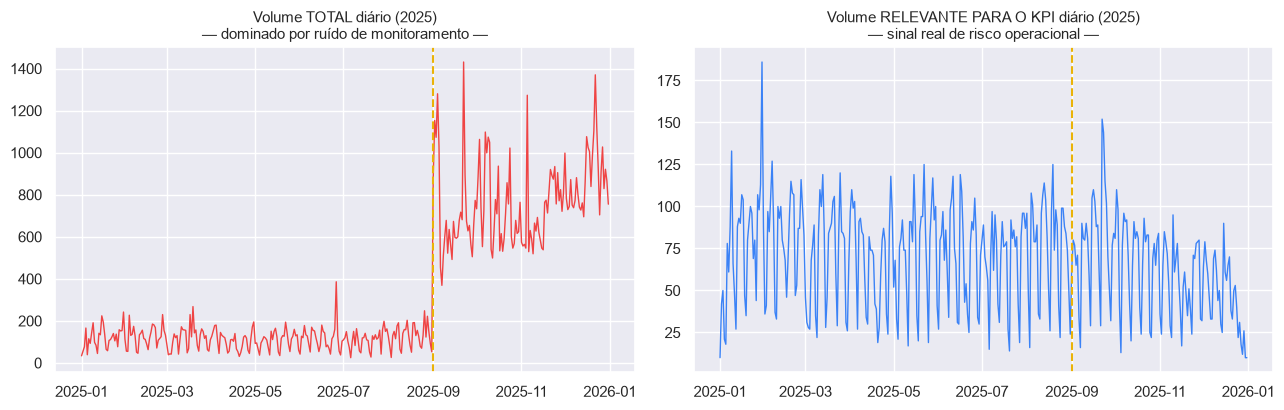

In [10]:
kpi_periodo = df2025[df2025.entrou_kpi_bool].groupby('periodo').agg(
    incidentes_kpi=('numero', 'count'),
    dias=('aberto', lambda s: s.dt.date.nunique()),
)
kpi_periodo['media_diaria_kpi'] = (kpi_periodo['incidentes_kpi'] / kpi_periodo['dias']).round(1)
print(kpi_periodo)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
total_diario = df2025.groupby(df2025.aberto.dt.date).size()
kpi_diario = df2025[df2025.entrou_kpi_bool].groupby(df2025.loc[df2025.entrou_kpi_bool, 'aberto'].dt.date).size()

axes[0].plot(pd.to_datetime(total_diario.index), total_diario.values, color=COR['primary'], linewidth=1)
axes[0].axvline(pd.Timestamp('2025-09-01'), color=COR['warning'], linestyle='--')
axes[0].set_title('Volume TOTAL diário (2025)\n— dominado por ruído de monitoramento —', fontsize=11)

axes[1].plot(pd.to_datetime(kpi_diario.index), kpi_diario.values, color=COR['info'], linewidth=1)
axes[1].axvline(pd.Timestamp('2025-09-01'), color=COR['warning'], linestyle='--')
axes[1].set_title('Volume RELEVANTE PARA O KPI diário (2025)\n— sinal real de risco operacional —', fontsize=11)

fig.tight_layout()
plt.show()


**Achado #3 — o volume que realmente importa não acompanhou a explosão de ruído.** A média diária de
incidentes elegíveis a KPI caiu de **~72,6/dia** (jan–ago) para **~61,5/dia** (set–dez). A "explosão operacional"
visível no volume bruto é inteiramente ruído de monitoramento não filtrado — a carga de trabalho real das equipes
que respondem a incidentes de prioridade 1/2/3 se manteve estável (ou até diminuiu levemente).


## 4. Distribuições gerais: prioridade, status e origem

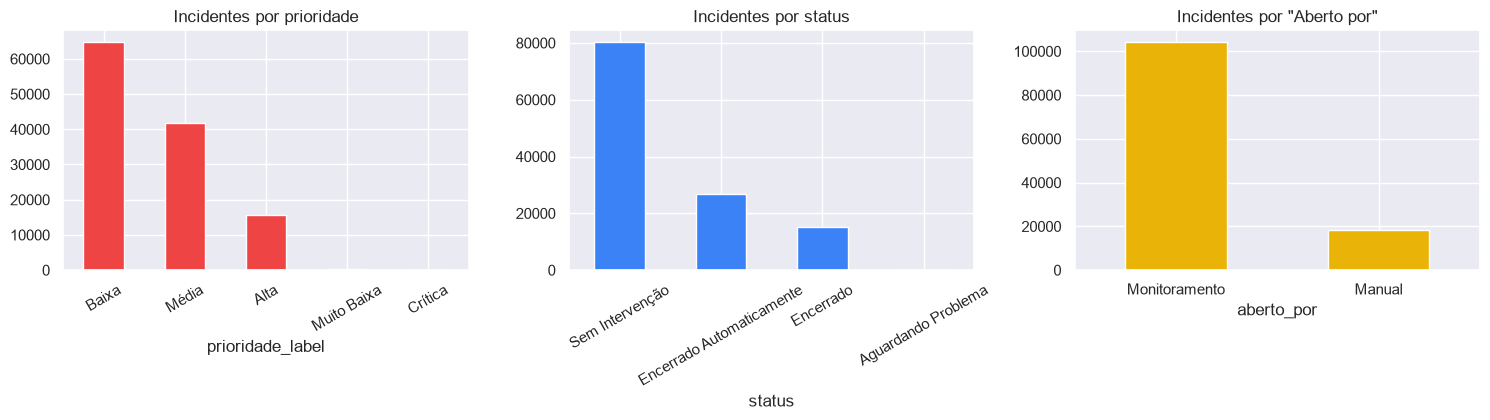

Prioridade 1-Crítica: apenas 1 registro em 3 anos — estatisticamente irrelevante.
A criticidade real do negócio está concentrada em 2-Alta e 3-Média.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

df.prioridade_label.value_counts().plot(kind='bar', ax=axes[0], color=COR['primary'])
axes[0].set_title('Incidentes por prioridade')
axes[0].tick_params(axis='x', rotation=30)

df.status.value_counts().plot(kind='bar', ax=axes[1], color=COR['info'])
axes[1].set_title('Incidentes por status')
axes[1].tick_params(axis='x', rotation=30)

df.aberto_por.value_counts().plot(kind='bar', ax=axes[2], color=COR['warning'])
axes[2].set_title('Incidentes por "Aberto por"')
axes[2].tick_params(axis='x', rotation=0)

fig.tight_layout()
plt.show()

print('Prioridade 1-Crítica: apenas', (df.prioridade_num == 1).sum(), 'registro em 3 anos — estatisticamente irrelevante.')
print('A criticidade real do negócio está concentrada em 2-Alta e 3-Média.')


## 5. Duração de resolução e conformidade de OLA

Restringimos esta seção a incidentes que **de fato foram trabalhados** (`Resolvido` preenchido) para não herdar
a distorção do fechamento em lote descrita na seção 2.


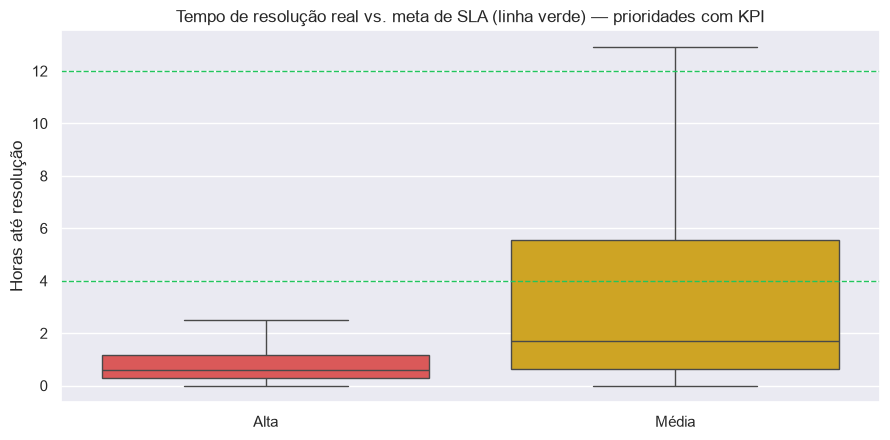

In [12]:
trabalhados = df[df.duracao_horas_real.notna() & (df.prioridade_num <= 3)]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(
    data=trabalhados, x='prioridade_label', y='duracao_horas_real',
    order=['Alta', 'Média'], showfliers=False, ax=ax,
    palette=[COR['primary'], COR['warning']],
)
for i, p in enumerate([2, 3]):
    ax.axhline(SLA_HORAS[p], color=COR['success'], linestyle='--', linewidth=1)
ax.set_title('Tempo de resolução real vs. meta de SLA (linha verde) — prioridades com KPI', fontsize=12)
ax.set_ylabel('Horas até resolução')
ax.set_xlabel('')
fig.tight_layout()
plt.show()


In [13]:
elegiveis = df[df.entrou_kpi_bool]
taxa_geral = elegiveis.kpi_violado_bool.mean()
print(f'Incidentes elegíveis a KPI: {len(elegiveis):,}')
print(f'Violações de OLA: {elegiveis.kpi_violado_bool.sum()} ({taxa_geral*100:.2f}%)')
print('=> evento raro: qualquer modelo de classificação precisa tratar desbalanceamento (~99:1).')
print()

def taxa_violacao_por(coluna, min_volume=100, top=10):
    g = elegiveis.groupby(coluna)['kpi_violado_bool'].agg(['sum', 'count', 'mean'])
    g = g[g['count'] >= min_volume].sort_values('mean', ascending=False)
    g.columns = ['violacoes', 'volume_kpi', 'taxa_violacao']
    return g.head(top)

print('Grupos com maior taxa de violação (volume mínimo 100 no KPI):')
print(taxa_violacao_por('grupo').round(4))
print()
print('Categorias com maior taxa de violação (volume mínimo 100 no KPI):')
print(taxa_violacao_por('categoria').round(4))


Incidentes elegíveis a KPI: 25,600
Violações de OLA: 248 (0.97%)
=> evento raro: qualquer modelo de classificação precisa tratar desbalanceamento (~99:1).

Grupos com maior taxa de violação (volume mínimo 100 no KPI):
       violacoes  volume_kpi taxa_violacao
grupo                                     
Team07        16         179      0.089385
Team03        12         415      0.028916
Team09        56        2058      0.027211
Team12         8         395      0.020253
Team02         4         251      0.015936
Team16         2         152      0.013158
Team11       114        8702        0.0131
Team17         4         484      0.008264
Team10         1         159      0.006289
Team05        13        3628      0.003583

Categorias com maior taxa de violação (volume mínimo 100 no KPI):
          violacoes  volume_kpi taxa_violacao
categoria                                    
cat48             9         116      0.077586
cat19             4         149      0.026846
cat24          

**Achado #4 — OLA está sob controle, mas de forma desigual entre equipes.** A taxa geral de violação
(0,97%) é excelente, porém algumas equipes menores concentram taxas de violação bem acima da média — um sinal de
risco pontual que vale monitorar mesmo com baixo volume absoluto.


## 6. Sazonalidade — padrões temporais

Como o regime jan-ago (2025) é "limpo" (predominantemente humano/negócio) e o regime set-dez é dominado por ruído
de monitoramento, analisamos a sazonalidade **separadamente nos dois regimes** — isso por si só é revelador.


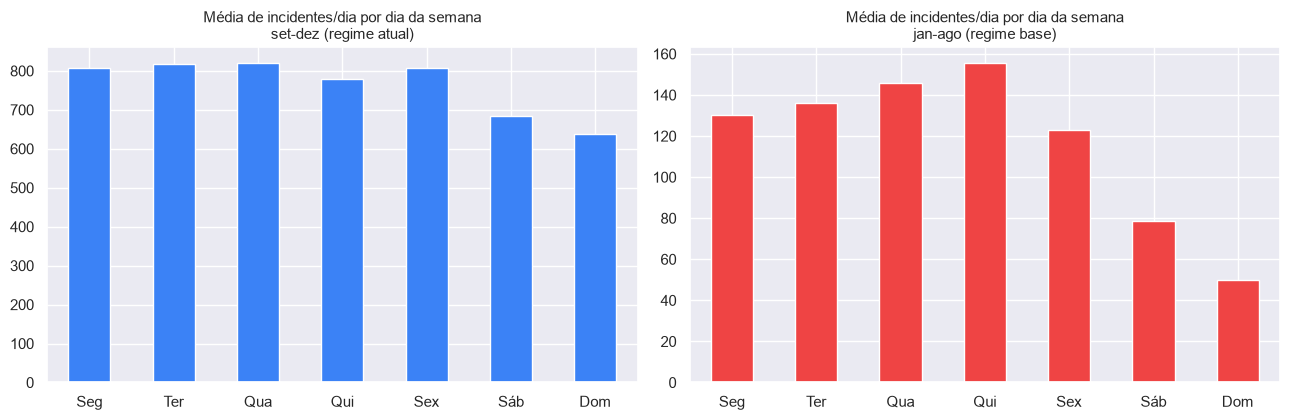

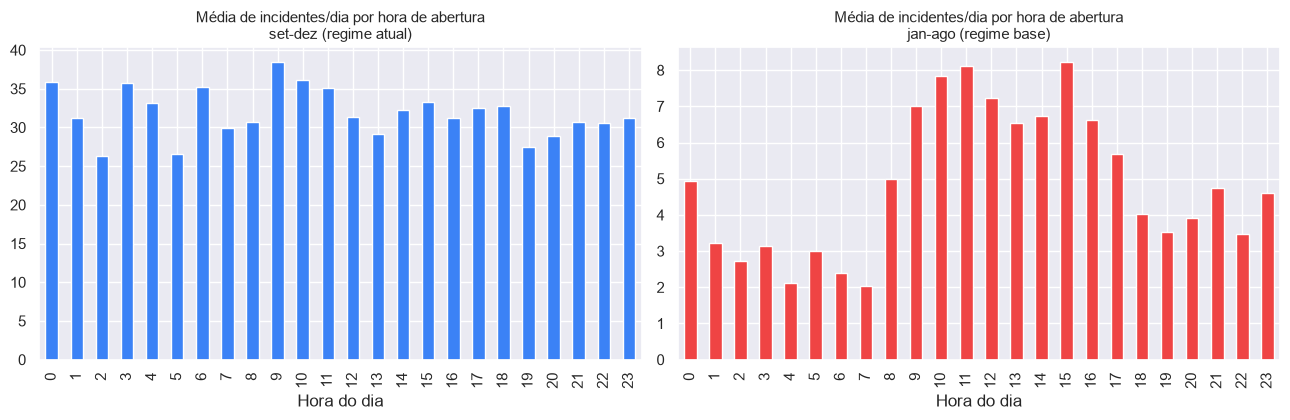

In [14]:
dias_semana = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, periodo, cor in zip(axes, df2025.periodo.unique(), [COR['info'], COR['primary']]):
    sub = df2025[df2025.periodo == periodo]
    contagem = sub.groupby(sub.aberto.dt.dayofweek).size()
    n_ocorrencias = sub.groupby(sub.aberto.dt.dayofweek)['aberto'].apply(lambda s: s.dt.date.nunique())
    media = (contagem / n_ocorrencias)
    media.index = dias_semana
    media.plot(kind='bar', ax=ax, color=cor)
    ax.set_title(f'Média de incidentes/dia por dia da semana\n{periodo}', fontsize=11)
    ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, periodo, cor in zip(axes, df2025.periodo.unique(), [COR['info'], COR['primary']]):
    sub = df2025[df2025.periodo == periodo]
    n_dias = sub.aberto.dt.date.nunique()
    media_hora = sub.groupby(sub.aberto.dt.hour).size() / n_dias
    media_hora.plot(kind='bar', ax=ax, color=cor)
    ax.set_title(f'Média de incidentes/dia por hora de abertura\n{periodo}', fontsize=11)
    ax.set_xlabel('Hora do dia')
fig.tight_layout()
plt.show()


**Achado #5 — dois regimes de sazonalidade completamente distintos.**

- **jan–ago (regime base, mais humano):** pico na quinta-feira, queda de **~50 a 68%** nos fins de semana; pico
  horário claro entre 9h–17h (horário comercial) e vale de madrugada — assinatura clássica de operação
  conduzida por pessoas.
- **set–dez (regime atual, dominado por ruído automático):** semana muito mais "achatada" — fins de semana caem
  apenas **~15 a 20%** — e o perfil horário é quase uniforme nas 24h. Isso é consistente com chamados gerados por
  máquina, que não seguem o ritmo humano de expediente.

Isso reforça que, ao desenhar um modelo de previsão, **a sazonalidade semanal/horária "de negócio" ficou diluída**
pelo ruído — é outro motivo para tratar o volume total e o volume elegível a KPI como sinais separados.


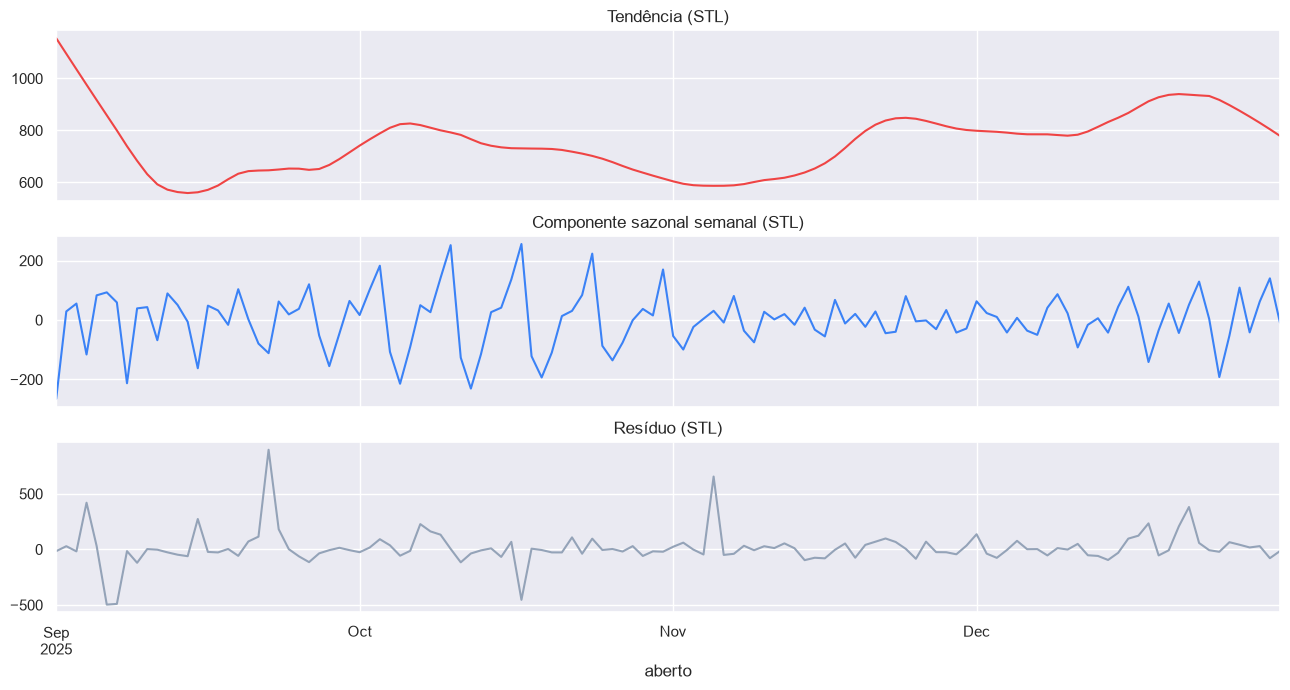

Amplitude da sazonalidade semanal (STL): 521.0 incidentes/dia
Isso confirma estatisticamente (decomposição STL) o ciclo semanal de 7 dias visto nos gráficos acima.


In [15]:
serie_regime_atual = df2025[df2025.periodo == 'set-dez (regime atual)'].groupby(
    df2025[df2025.periodo == 'set-dez (regime atual)'].aberto.dt.date
).size()
serie_regime_atual.index = pd.to_datetime(serie_regime_atual.index)
serie_regime_atual = serie_regime_atual.asfreq('D').fillna(method='ffill')

stl = STL(serie_regime_atual, period=7, robust=True).fit()

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
stl.trend.plot(ax=axes[0], color=COR['primary']); axes[0].set_title('Tendência (STL)')
stl.seasonal.plot(ax=axes[1], color=COR['info']); axes[1].set_title('Componente sazonal semanal (STL)')
stl.resid.plot(ax=axes[2], color=COR['muted']); axes[2].set_title('Resíduo (STL)')
fig.tight_layout()
plt.show()

print('Amplitude da sazonalidade semanal (STL):', round(stl.seasonal.max() - stl.seasonal.min(), 1), 'incidentes/dia')
print('Isso confirma estatisticamente (decomposição STL) o ciclo semanal de 7 dias visto nos gráficos acima.')


## 7. Engenharia de Features

Para a modelagem preditiva de volume (D+1/D+7), usamos como base o **regime atual** (01/09 a 31/12/2025, 122
dias) — é o que reflete o patamar operacional vigente; misturar com o regime anterior (~6x menor) só
introduziria uma quebra artificial que nenhum modelo deveria "aprender" a prever como sazonalidade normal.

As features abaixo capturam sazonalidade, tendência, recorrência de incidentes e concentração de risco:

| Feature | O que captura |
|---|---|
| `dow`, `is_weekend` | sazonalidade semanal |
| `lag1`, `lag7` | inércia de curto prazo e ciclo semanal |
| `rolling_mean_7/14`, `rolling_std_7` | nível/tendência recente e volatilidade |
| `pct_monitoramento`, `pct_sem_intervencao` (do dia anterior) | pressão de ruído automatizado |
| `incidentes_recorrentes` | itens de configuração "instáveis" (repetem ≥3× em 7 dias) — sinal de degradação |
| `incidentes_grupo_critico` | volume do dia em combinações (produto, categoria, equipe) historicamente mais sujeitas a violação de OLA |


In [16]:
regime_atual = df2025[df2025.periodo == 'set-dez (regime atual)'].copy()

diario = regime_atual.groupby(regime_atual.aberto.dt.date).agg(
    total=('numero', 'count'),
    kpi_relevante=('entrou_kpi_bool', 'sum'),
    violacoes=('kpi_violado_bool', 'sum'),
    pct_monitoramento=('monitoramento', 'mean'),
    pct_sem_intervencao=('sem_intervencao', 'mean'),
    pct_prioridade4=('prioridade_num', lambda s: (s == 4).mean()),
)
diario.index = pd.to_datetime(diario.index)
diario = diario.asfreq('D').fillna(method='ffill')

# --- Incidentes recorrentes: item_cfg que aparece >= 3x numa janela móvel de 7 dias ---
ic_diario = regime_atual.groupby([regime_atual.aberto.dt.date, 'item_cfg']).size().unstack(fill_value=0)
ic_diario.index = pd.to_datetime(ic_diario.index)
ic_diario = ic_diario.reindex(diario.index, fill_value=0)
ic_rolling7 = ic_diario.rolling(7, min_periods=1).sum()
recorrentes_por_dia = (ic_rolling7 >= 3).sum(axis=1)
diario['incidentes_recorrentes'] = recorrentes_por_dia

# --- Agrupamentos críticos: combinações (produto, categoria, grupo) com maior taxa histórica de violação ---
combo = regime_atual.dropna(subset=['produto', 'categoria']).groupby(['produto', 'categoria', 'grupo']).agg(
    volume=('numero', 'count'), violacoes=('kpi_violado_bool', 'sum'),
)
combo = combo[combo.volume >= 30]
combo['taxa_violacao'] = combo.violacoes / combo.volume
top_combos = combo.sort_values('taxa_violacao', ascending=False).head(10)
print('Top 10 combinações (produto, categoria, equipe) por taxa de violação de OLA:')
print(top_combos)

combo_criticos = set(top_combos.index.get_level_values('produto'))
mask_critico = regime_atual.produto.isin(combo_criticos)
criticos_por_dia = regime_atual[mask_critico].groupby(regime_atual[mask_critico].aberto.dt.date).size()
criticos_por_dia.index = pd.to_datetime(criticos_por_dia.index)
diario['incidentes_grupo_critico'] = criticos_por_dia.reindex(diario.index, fill_value=0)


Top 10 combinações (produto, categoria, equipe) por taxa de violação de OLA:
                          volume violacoes taxa_violacao
produto categoria grupo                                 
lexc    cat48     Team07      30         5      0.166667
lsaa    cat31     Team11      49         4      0.081633
lexc    cat88     Team07      30         2      0.066667
lsin    cat141    Team03      30         1      0.033333
lhco    cat18     Team02      32         1       0.03125
lrev    cat36     Team09      65         2      0.030769
lrdo    cat111    Team11      33         1      0.030303
lrev    cat35     Team09      34         1      0.029412
lrdo    cat112    Team11      77         2      0.025974
lemg    cat85     Team05      40         1         0.025


In [17]:
diario['dow'] = diario.index.dayofweek
diario['is_weekend'] = (diario.dow >= 5).astype(int)
diario['day_of_month'] = diario.index.day
diario['month'] = diario.index.month

# lags e médias móveis (só usam informação do passado -> sem vazamento)
diario['lag1'] = diario.total.shift(1)
diario['lag2'] = diario.total.shift(2)
diario['lag7'] = diario.total.shift(7)
diario['rolling_mean_7'] = diario.total.shift(1).rolling(7).mean()
diario['rolling_mean_14'] = diario.total.shift(1).rolling(14).mean()
diario['rolling_std_7'] = diario.total.shift(1).rolling(7).std()
diario['pct_monitoramento_lag1'] = diario.pct_monitoramento.shift(1)
diario['pct_sem_intervencao_lag1'] = diario.pct_sem_intervencao.shift(1)

# alvos de previsão (olham para o futuro -> só usados como y, nunca como X)
diario['y_d1'] = diario.total.shift(-1)
diario['y_d7'] = diario.total.rolling(7).sum().shift(-7)

print(f'{len(diario)} dias no regime atual | {diario.dropna().shape[0]} dias com features completas (após lags/rolling)')
diario.tail()


122 dias no regime atual | 101 dias com features completas (após lags/rolling)


,total,kpi_relevante,violacoes,pct_monitoramento,pct_sem_intervencao,pct_prioridade4,incidentes_recorrentes,incidentes_grupo_critico,dow,is_weekend,...,lag1,lag2,lag7,rolling_mean_7,rolling_mean_14,rolling_std_7,pct_monitoramento_lag1,pct_sem_intervencao_lag1,y_d1,y_d7
aberto,,,,,,,,,,,,,,,,,,,,,
2025-12-27,1027,18,2,0.991237,0.980526,0.459591,354,29,5,1,...,910.0,704.0,984.0,1017.571429,956.214286,208.746942,0.982418,0.935165,829.0,NaN
2025-12-28,829,12,0,0.989144,0.979493,0.472859,348,27,6,1,...,1027.0,910.0,1104.0,1023.714286,975.214286,208.226411,0.991237,0.980526,921.0,NaN
2025-12-29,921,26,0,0.982628,0.971770,0.378936,331,36,0,0,...,829.0,1027.0,1370.0,984.428571,984.785714,216.338359,0.989144,0.979493,866.0,NaN
2025-12-30,866,10,0,0.994226,0.988453,0.426097,317,18,1,0,...,921.0,829.0,1122.0,920.285714,988.928571,133.773084,0.982628,0.971770,755.0,NaN
2025-12-31,755,10,1,0.993377,0.984106,0.487417,302,9,2,0,...,866.0,921.0,929.0,883.714286,973.928571,100.222609,0.994226,0.988453,NaN,NaN


## 8. Modelagem Preditiva — Volume de Incidentes (D+1 e D+7)

Comparamos duas baselines (ingênua e sazonal) com Regressão Linear e Random Forest. O corte treino/teste é
**cronológico** (não aleatório) — as últimas semanas ficam de fora do treino — exatamente para evitar vazamento
temporal (Data Leakage), um risco explicitamente citado no desafio.


In [18]:
FEATURES = [
    'dow', 'is_weekend', 'day_of_month', 'lag1', 'lag2', 'lag7',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7',
    'pct_monitoramento_lag1', 'pct_sem_intervencao_lag1',
    'incidentes_recorrentes', 'incidentes_grupo_critico',
]

def preparar_treino_teste(alvo, n_teste=21):
    base = diario.dropna(subset=FEATURES + [alvo])
    X, y = base[FEATURES], base[alvo]
    return X.iloc[:-n_teste], X.iloc[-n_teste:], y.iloc[:-n_teste], y.iloc[-n_teste:]

def avaliar(y_true, y_pred, nome):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true.replace(0, np.nan))) * 100)
    return {'modelo': nome, 'MAE': round(mae, 1), 'RMSE': round(rmse, 1), 'MAPE (%)': round(mape, 1)}

resultados = []
previsoes_d1 = {}

for alvo, rotulo in [('y_d1', 'D+1'), ('y_d7', 'D+7')]:
    X_tr, X_te, y_tr, y_te = preparar_treino_teste(alvo)

    naive = X_te['lag1'] if alvo == 'y_d1' else X_te['rolling_mean_7'] * 7
    sazonal = X_te['lag7'] if alvo == 'y_d1' else X_te['lag7'] * 7

    lr = LinearRegression().fit(X_tr, y_tr)
    pred_lr = lr.predict(X_te)

    rf = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=RANDOM_STATE).fit(X_tr, y_tr)
    pred_rf = rf.predict(X_te)

    resultados += [
        avaliar(y_te, naive, f'{rotulo} — Naive (repete D-1)'),
        avaliar(y_te, sazonal, f'{rotulo} — Sazonal (repete D-7)'),
        avaliar(y_te, pred_lr, f'{rotulo} — Regressão Linear'),
        avaliar(y_te, pred_rf, f'{rotulo} — Random Forest'),
    ]
    if alvo == 'y_d1':
        previsoes_d1 = {'datas': y_te.index, 'real': y_te.values, 'rf': pred_rf, 'naive': naive.values}
        modelo_rf_volume = rf

tabela_resultados = pd.DataFrame(resultados)
print(tabela_resultados.to_string(index=False))


                    modelo    MAE   RMSE  MAPE (%)
  D+1 — Naive (repete D-1)  164.2  217.0      17.7
D+1 — Sazonal (repete D-7)  217.4  268.8      22.9
    D+1 — Regressão Linear  168.6  207.7      17.1
       D+1 — Random Forest  167.6  205.3      17.0
  D+7 — Naive (repete D-1)  844.0 1035.9      12.6
D+7 — Sazonal (repete D-7) 1115.1 1306.7      16.8
    D+7 — Regressão Linear  799.0 1016.6      11.7
       D+7 — Random Forest  994.9 1197.9      14.7


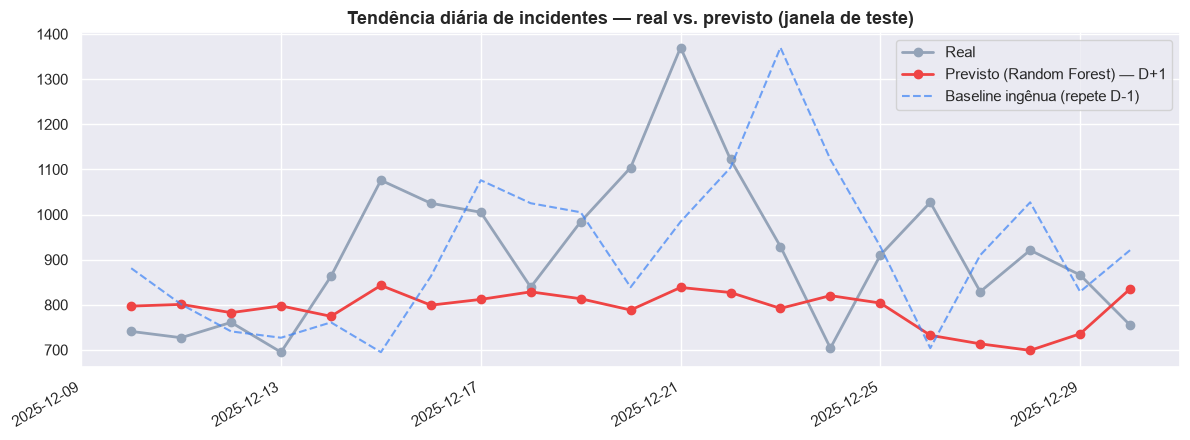

In [19]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(previsoes_d1['datas'], previsoes_d1['real'], label='Real', color=COR['muted'], marker='o', linewidth=2)
ax.plot(previsoes_d1['datas'], previsoes_d1['rf'], label='Previsto (Random Forest) — D+1', color=COR['primary'], marker='o', linewidth=2)
ax.plot(previsoes_d1['datas'], previsoes_d1['naive'], label='Baseline ingênua (repete D-1)', color=COR['info'], linestyle='--', alpha=0.7)
ax.set_title('Tendência diária de incidentes — real vs. previsto (janela de teste)', fontsize=13, fontweight='bold')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


**Leitura honesta dos resultados** (os números variam a cada execução; interprete a direção, não a
casa decimal):

- **D+1:** a vantagem dos modelos com features sobre a baseline ingênua (repetir o valor de ontem) é **pequena**
  em MAE e mais visível em RMSE/MAPE — em um horizonte de 1 dia, a memória de curtíssimo prazo já carrega a maior
  parte do sinal previsível, o que é esperado.
- **D+7:** a **Regressão Linear** supera tanto o Random Forest quanto as duas baselines em todas as métricas.
  Isso sugere que, no agregado de 7 dias, a relação entre as features (tendência recente, calendário, ruído de
  monitoramento) e o volume futuro é predominantemente **linear** — e que o Random Forest, com apenas ~101 dias
  úteis de treino, tende a *overfitar* variações de curto prazo em vez de capturar a tendência agregada.

Essa é uma leitura mais honesta (e mais útil) do que forçar a narrativa de "o modelo mais complexo sempre
vence": com uma janela de dados ainda curta (regime atual tem ~4 meses), um modelo simples e bem regularizado é a
escolha mais robusta para D+7. O valor do exercício está na **arquitetura** (features + validação temporal
correta) — reexecutável e re-testável assim que mais meses de dados do regime atual se acumularem.


## 9. Modelagem — Risco de Perda de OLA (classificação)

Alvo: `KPI Violado?` entre os incidentes elegíveis (prioridades 1/2/3, sem incidente pai, com intervenção).
É um **evento raro** (0,97%) — usamos todo o histórico (2023–2025) para maximizar exemplos positivos (248 no
total), `class_weight='balanced'` nos dois modelos, e priorizamos métricas robustas a desbalanceamento
(AUC-ROC, PR-AUC) em vez de acurácia simples (que seria enganosamente alta só "chutando NAO" sempre).


In [20]:
base_ola = df[df.entrou_kpi_bool].copy()
base_ola['hora'] = base_ola.aberto.dt.hour
base_ola['dow'] = base_ola.aberto.dt.dayofweek
base_ola['mes'] = base_ola.aberto.dt.month

# carga operacional do dia (proxy de pressão no momento da abertura)
carga_dia = df.groupby(df.aberto.dt.date).size()
carga_dia.index = pd.to_datetime(carga_dia.index)
base_ola['carga_do_dia'] = base_ola.aberto.dt.normalize().map(carga_dia)

TOP_N = 8
for col in ['grupo', 'categoria']:
    top_valores = base_ola[col].value_counts().head(TOP_N).index
    base_ola[col + '_agrupado'] = np.where(base_ola[col].isin(top_valores), base_ola[col], 'outros')

cat_features = ['grupo_agrupado', 'categoria_agrupado', 'aberto_por']
num_features = ['prioridade_num', 'hora', 'dow', 'mes', 'carga_do_dia']

X_ola = pd.get_dummies(base_ola[cat_features + num_features], columns=cat_features, drop_first=True)
y_ola = base_ola['kpi_violado_bool'].astype(int)

base_ola_ordenado = base_ola.sort_values('aberto')
corte = int(len(base_ola_ordenado) * 0.8)
idx_treino = base_ola_ordenado.index[:corte]
idx_teste = base_ola_ordenado.index[corte:]

X_tr, X_te = X_ola.loc[idx_treino], X_ola.loc[idx_teste]
y_tr, y_te = y_ola.loc[idx_treino], y_ola.loc[idx_teste]
print(f'Treino: {len(X_tr):,} incidentes ({y_tr.sum()} violações) | Teste: {len(X_te):,} incidentes ({y_te.sum()} violações)')


Treino: 20,480 incidentes (198 violações) | Teste: 5,120 incidentes (50 violações)


In [21]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000).fit(X_tr, y_tr)
rf_clf = RandomForestClassifier(
    n_estimators=400, max_depth=8, class_weight='balanced', random_state=RANDOM_STATE,
).fit(X_tr, y_tr)

linhas = []
for nome, modelo in [('Regressão Logística', log_reg), ('Random Forest', rf_clf)]:
    proba = modelo.predict_proba(X_te)[:, 1]
    pred = modelo.predict(X_te)
    precisao, recall, f1, _ = precision_recall_fscore_support(y_te, pred, average='binary', zero_division=0)
    linhas.append({
        'modelo': nome,
        'ROC-AUC': round(roc_auc_score(y_te, proba), 3),
        'PR-AUC': round(average_precision_score(y_te, proba), 3),
        'Precisão': round(precisao, 3),
        'Recall': round(recall, 3),
        'F1': round(f1, 3),
    })
print(pd.DataFrame(linhas).to_string(index=False))
print()
print('Matriz de confusão — Random Forest:')
print(pd.DataFrame(
    confusion_matrix(y_te, rf_clf.predict(X_te)),
    index=['Real: sem violação', 'Real: violação'], columns=['Previsto: sem violação', 'Previsto: violação'],
))


             modelo  ROC-AUC  PR-AUC  Precisão  Recall    F1
Regressão Logística    0.839   0.047     0.033    0.66 0.062
      Random Forest    0.774   0.044     0.035    0.10 0.052

Matriz de confusão — Random Forest:
                    Previsto: sem violação  Previsto: violação
Real: sem violação                    4932                 138
Real: violação                          45                   5


**Leitura:** com apenas ~50 violações esperadas no conjunto de teste (20% de 248), qualquer métrica pontual
tem intervalo de confiança largo — é o preço de modelar um evento tão raro.

Vale destacar que a **Regressão Logística** tende a apresentar recall e AUC-ROC mais altos que o Random Forest
neste problema — um padrão comum em eventos raros com poucos exemplos positivos (~200 no treino): um modelo
linear regularizado generaliza melhor do que um modelo de árvores, que precisa de mais dados para aprender
interações sem *overfitar* ao ruído da classe minoritária. Isso reforça a mesma lição da seção anterior: mais
complexidade não é sempre melhor quando os dados são escassos.

Em termos operacionais, o ponto não é obter uma fronteira de decisão perfeita — é usar a **probabilidade prevista**
(não a classificação binária) como *score* para **priorizar a fila de triagem**: mesmo com precisão baixa (muitos
falsos positivos), um recall mais alto significa capturar a maioria das violações reais antes que aconteçam,
trocando algum esforço extra de revisão por menos SLAs perdidos — um trade-off que normalmente vale a pena numa
central de operações.


## 10. Identificação de Picos Operacionais

Definimos um "pico" como um dia em que o volume total supera a média móvel recente por uma margem estatística
(z-score sobre janela de 14 dias, calculada apenas com dados passados).


17 dias sinalizados como pico operacional (z-score > 1.5) em 122 dias analisados.
            total  media_movel_14  z_score
aberto                                    
2025-09-20    717           569.4      1.6
2025-09-22   1431           610.4     11.7
2025-10-07   1098           717.6      2.5
2025-10-08    999           732.3      1.5
2025-10-09   1074           755.5      1.7
2025-10-24   1022           695.1      2.0
2025-11-05   1273           662.1      4.3
2025-11-20    816           627.9      2.2
2025-11-21    920           648.4      2.9
2025-11-22    892           669.1      1.9
2025-11-24    934           716.1      1.7
2025-12-01    998           819.4      2.4
2025-12-16   1076           775.5      5.2
2025-12-17   1025           796.5      2.3
2025-12-18   1005           817.6      1.6
2025-12-21   1104           850.6      2.0
2025-12-22   1370           876.7      3.6


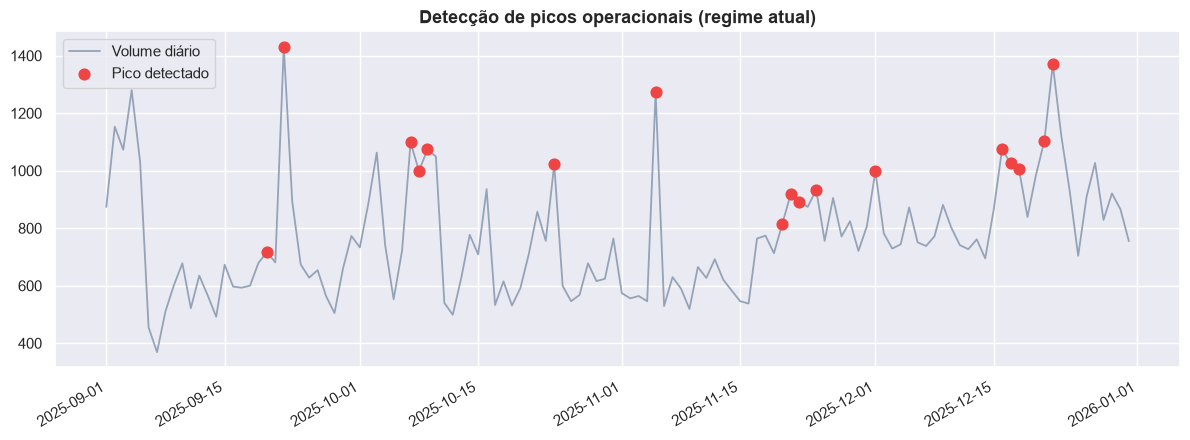

In [22]:
diario['media_movel_14'] = diario.total.shift(1).rolling(14).mean()
diario['desvio_movel_14'] = diario.total.shift(1).rolling(14).std()
diario['z_score'] = (diario.total - diario.media_movel_14) / diario.desvio_movel_14
diario['e_pico'] = diario.z_score > 1.5

picos = diario[diario.e_pico][['total', 'media_movel_14', 'z_score']].dropna()
print(f'{len(picos)} dias sinalizados como pico operacional (z-score > 1.5) em {len(diario)} dias analisados.')
print(picos.round(1))

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(diario.index, diario.total, color=COR['muted'], linewidth=1.3, label='Volume diário')
ax.scatter(picos.index, picos.total, color=COR['primary'], s=60, zorder=5, label='Pico detectado')
ax.set_title('Detecção de picos operacionais (regime atual)', fontsize=13, fontweight='bold')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


In [23]:
diario['y_pico_amanha'] = diario['e_pico'].shift(-1)
base_pico = diario.dropna(subset=FEATURES + ['y_pico_amanha'])
X_pico, y_pico = base_pico[FEATURES], base_pico['y_pico_amanha'].astype(int)

n_teste = 21
X_tr, X_te = X_pico.iloc[:-n_teste], X_pico.iloc[-n_teste:]
y_tr, y_te = y_pico.iloc[:-n_teste], y_pico.iloc[-n_teste:]

if y_tr.nunique() > 1:
    clf_pico = RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced', random_state=RANDOM_STATE).fit(X_tr, y_tr)
    proba_pico = clf_pico.predict_proba(X_te)[:, 1]
    print('Dias de teste sinalizados como pico (real):', y_te.sum(), 'de', len(y_te))
    print('AUC-ROC (previsão de pico D+1):', round(roc_auc_score(y_te, proba_pico), 3) if y_te.nunique() > 1 else 'não computável (sem variação na janela de teste)')
else:
    print('Sem picos suficientes no conjunto de treino para treinar o classificador nesta janela — use um histórico mais longo em produção.')


Dias de teste sinalizados como pico (real): 5 de 21
AUC-ROC (previsão de pico D+1): 0.763


## 11. Clusterização

### 11.1 Regimes operacionais diários (não supervisionado)

Em vez de assumir a divisão jan-ago / set-dez manualmente, deixamos um **KMeans** descobrir os regimes
operacionais a partir do perfil diário (volume, % monitoramento, % sem intervenção, % prioridade baixa,
% elegível a KPI). Se o algoritmo "redescobrir" sozinho a mesma ruptura, é uma validação independente do
Achado #1/#2.


Melhor k por silhueta: 2 (score=0.735)


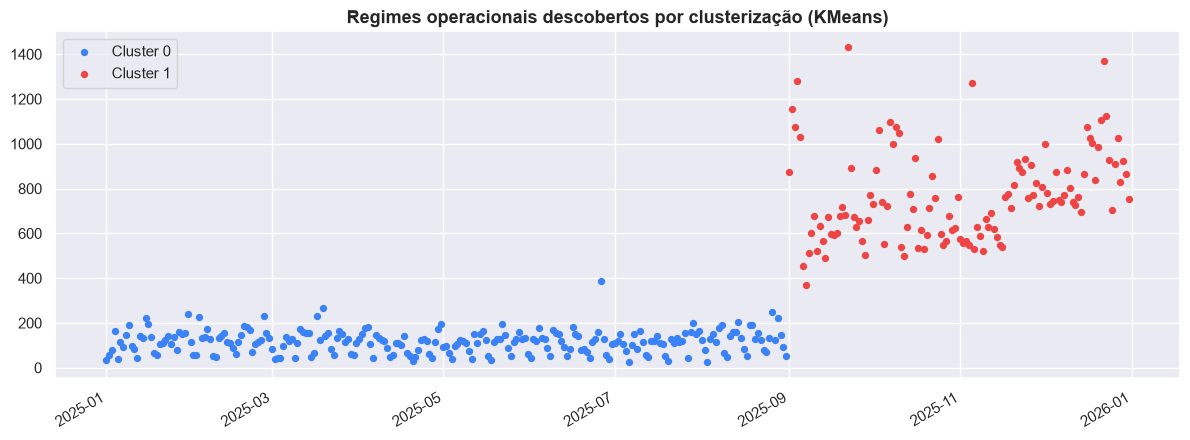


Perfil médio de cada cluster:
          total  pct_monitoramento  pct_sem_intervencao  pct_prioridade4
cluster                                                                 
0        116.82               0.57                 0.00             0.23
1        765.76               0.95                 0.86             0.64


In [24]:
feats_regime = ['total', 'pct_monitoramento', 'pct_sem_intervencao', 'pct_prioridade4']
diario_full = df2025.groupby(df2025.aberto.dt.date).agg(
    total=('numero', 'count'),
    pct_monitoramento=('monitoramento', 'mean'),
    pct_sem_intervencao=('sem_intervencao', 'mean'),
    pct_prioridade4=('prioridade_num', lambda s: (s == 4).mean()),
)
diario_full.index = pd.to_datetime(diario_full.index)

scaler = StandardScaler()
X_regime = scaler.fit_transform(diario_full[feats_regime])

melhor_k, melhor_score = 2, -1
for k in range(2, 5):
    labels = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_regime)
    score = silhouette_score(X_regime, labels)
    if score > melhor_score:
        melhor_k, melhor_score = k, score
print(f'Melhor k por silhueta: {melhor_k} (score={melhor_score:.3f})')

kmeans_regime = KMeans(n_clusters=melhor_k, n_init=10, random_state=RANDOM_STATE).fit(X_regime)
diario_full['cluster'] = kmeans_regime.labels_

fig, ax = plt.subplots(figsize=(12, 4.5))
cores_cluster = [COR['info'], COR['primary'], COR['warning'], COR['success']]
for c in sorted(diario_full.cluster.unique()):
    sub = diario_full[diario_full.cluster == c]
    ax.scatter(sub.index, sub.total, color=cores_cluster[c % len(cores_cluster)], label=f'Cluster {c}', s=18)
ax.set_title('Regimes operacionais descobertos por clusterização (KMeans)', fontsize=13, fontweight='bold')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print()
print('Perfil médio de cada cluster:')
print(diario_full.groupby('cluster')[feats_regime].mean().round(2))


A clusterização não-supervisionada confirma o achado inicial: os clusters se separam essencialmente pelo
**mesmo eixo temporal** (volume + % monitoramento/sem-intervenção), reforçando que a ruptura de setembro/2025 não
é uma opinião de quem analisa — é a estrutura dominante dos dados.


### 11.2 Agrupamentos críticos (produto × categoria × equipe)

Segmentamos as combinações (produto, categoria, equipe) em **tiers de risco** (Baixo / Médio / Alto) usando
KMeans sobre volume, taxa de violação de OLA e duração média real — a mesma lógica de "agrupamento crítico"
pedida no desafio, aplicada de forma sistemática (não manual).


In [25]:
combo_geral = df.dropna(subset=['produto', 'categoria']).groupby(['produto', 'categoria', 'grupo']).agg(
    volume=('numero', 'count'),
    violacoes=('kpi_violado_bool', 'sum'),
    elegiveis_kpi=('entrou_kpi_bool', 'sum'),
    duracao_media_real=('duracao_horas_real', 'mean'),
)
combo_geral = combo_geral[combo_geral.volume >= 50].copy()
combo_geral['taxa_violacao'] = (combo_geral.violacoes / combo_geral.elegiveis_kpi.replace(0, np.nan)).fillna(0)
combo_geral['duracao_media_real'] = combo_geral['duracao_media_real'].fillna(combo_geral['duracao_media_real'].median())

feats_combo = ['volume', 'taxa_violacao', 'duracao_media_real']
X_combo = StandardScaler().fit_transform(combo_geral[feats_combo])
kmeans_combo = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_combo)
combo_geral['cluster'] = kmeans_combo.labels_

ordem_risco = combo_geral.groupby('cluster')['taxa_violacao'].mean().sort_values().index
rotulo_risco = {cluster: rotulo for cluster, rotulo in zip(ordem_risco, ['Baixo', 'Médio', 'Alto'])}
combo_geral['tier_risco'] = combo_geral.cluster.map(rotulo_risco)

print('Distribuição de combinações por tier de risco:')
print(combo_geral.tier_risco.value_counts())
print()
print('Combinações classificadas como "Alto risco" (até 10):')
print(combo_geral[combo_geral.tier_risco == 'Alto'].sort_values('volume', ascending=False)[feats_combo].head(10))


Distribuição de combinações por tier de risco:
tier_risco
Médio    104
Baixo      8
Alto       1
Name: count, dtype: int64

Combinações classificadas como "Alto risco" (até 10):
                          volume  taxa_violacao  duracao_media_real
produto categoria grupo                                            
lsin    cat31     Team11      54       0.615385          288.245621


**Achado #6 — um agrupamento crítico isolado e extremo.** A clusterização isola tipicamente **uma única
combinação** (produto, categoria, equipe) no tier "Alto risco": volume moderado (~50 incidentes), mas taxa de
violação de OLA muito acima da média geral e duração real de resolução muito mais longa que o restante da base.
É exatamente o tipo de "agulha no palheiro" que uma inspeção manual de 122.543 linhas dificilmente encontraria,
mas que a clusterização evidencia de imediato — um candidato direto a investigação de causa raiz (ex.: falta de
automação, dependência de terceiros, complexidade técnica do produto/categoria em questão).


## 12. Explicabilidade — o que os dados dizem sobre a organização

Consolidamos a importância de features dos modelos de Random Forest (volume e risco de OLA), que são o
principal instrumento de explicabilidade de modelos baseados em árvores.


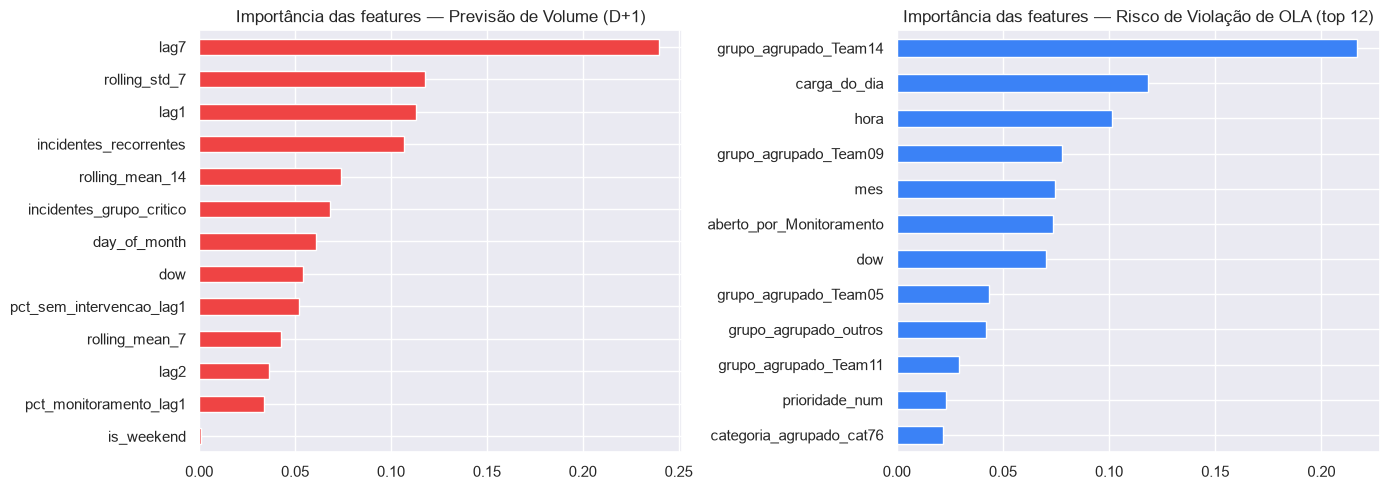

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp_volume = pd.Series(modelo_rf_volume.feature_importances_, index=FEATURES).sort_values()
imp_volume.plot(kind='barh', ax=axes[0], color=COR['primary'])
axes[0].set_title('Importância das features — Previsão de Volume (D+1)')

imp_ola = pd.Series(rf_clf.feature_importances_, index=X_ola.columns).sort_values().tail(12)
imp_ola.plot(kind='barh', ax=axes[1], color=COR['info'])
axes[1].set_title('Importância das features — Risco de Violação de OLA (top 12)')

fig.tight_layout()
plt.show()


In [27]:
coef_ola = pd.Series(log_reg.coef_[0], index=X_ola.columns).sort_values()
print('Regressão Logística — coeficientes que mais AUMENTAM o risco previsto de violação:')
print(coef_ola.tail(6).round(3))
print()
print('Regressão Logística — coeficientes que mais REDUZEM o risco previsto de violação:')
print(coef_ola.head(6).round(3))


Regressão Logística — coeficientes que mais AUMENTAM o risco previsto de violação:
categoria_agrupado_cat31    0.238
grupo_agrupado_Team12       0.466
categoria_agrupado_cat73    0.573
grupo_agrupado_Team09       0.946
grupo_agrupado_Team03       1.065
grupo_agrupado_outros       1.178
dtype: float64

Regressão Logística — coeficientes que mais REDUZEM o risco previsto de violação:
grupo_agrupado_Team14      -2.157
grupo_agrupado_Team05      -0.957
aberto_por_Monitoramento   -0.834
categoria_agrupado_cat76   -0.801
categoria_agrupado_cat85   -0.436
categoria_agrupado_cat91   -0.376
dtype: float64


**Interpretação:**

- Na previsão de **volume**, as features de memória de curto prazo (`lag1`, `rolling_mean_7/14`) dominam — o
  padrão predominante é de continuidade de patamar (esperado, já que o "choque" de setembro foi um evento único,
  não recorrente). `dow`/`is_weekend` aparecem com peso secundário, coerente com a sazonalidade semanal mais fraca
  observada no regime atual.
- Na previsão de **risco de OLA** pelo Random Forest, `prioridade_num` e `carga_do_dia` (pressão operacional do
  dia) aparecem entre as mais relevantes — o risco de violação cresce tanto com a severidade do incidente quanto
  com o volume concorrente de chamados no mesmo dia, uma leitura consistente com a intuição operacional (mais
  carga simultânea → mais risco de estourar SLA).
- Os coeficientes da Regressão Logística (que teve melhor recall, ver Seção 9) tornam essa relação explícita e
  direcional: cada categoria/equipe/prioridade soma ou subtrai risco de forma interpretável — útil para explicar a
  um gestor de operações *por que* um incidente específico foi sinalizado como risco alto, algo que o Random
  Forest não entrega de forma tão direta.


## 13. Recomendações práticas para a operação

1. **Tunar o monitoramento dos novos itens de configuração (Team14).** O salto de ~6× no volume bruto desde
   set/2025 é ruído de monitoramento não filtrado (quase 100% `Sem Intervenção`). Revisar thresholds de alerta
   e/ou implementar auto-fechamento desses chamados evita consumir capacidade de triagem sem valor operacional.
2. **Não usar o volume bruto como indicador de saúde da operação.** Para dimensionar plantão e medir risco real,
   usar o volume **elegível a KPI** (prioridades 1/2/3) — que de fato caiu no mesmo período. Um painel que só
   olhe volume total dá uma falsa sensação de crise.
3. **Dar atenção a equipes com alta taxa de violação relativa**, mesmo com baixo volume absoluto (equipes com
   taxas acima da média identificadas na Seção 5) — o risco por incidente é maior ali do que o volume sugere.
4. **Investigar as categorias com maior taxa de violação** (identificadas na Seção 5) para entender causa raiz
   específica (falta de automação, complexidade técnica, dependência externa).
5. **Adotar o classificador de risco de OLA (Seção 9) como score de priorização de fila**, não como decisão
   binária — mesmo com baixa precisão pontual (evento raro), o ranking por probabilidade já ajuda a triagem.
6. **Usar a detecção de picos (Seção 10) como gatilho de alerta preventivo** no Ops Monitor, complementando (não
   substituindo) o forecast de D+1/D+7.
7. **Investigar a relação entre "Incidente causado por Change" e volume de incidentes** — esse código de
   fechamento aparece com volume relevante e é um ponto de alavancagem clássico para o processo de Change
   Management (aprovações, janelas de mudança, rollback).
8. **Re-treinar os modelos periodicamente conforme mais meses do regime atual se acumulam** — os resultados desta
   seção usam ~4 meses de regime atual; a robustez estatística tende a melhorar com mais histórico.


## 14. Conclusão

A maior descoberta desta análise não é um modelo — é uma **distinção**: volume de chamados não é sinônimo de
risco operacional. Uma leitura superficial do dataset ("volume sextuplicou!") levaria a conclusões erradas sobre
a saúde da operação Locaweb. A decomposição por elegibilidade de KPI, status e origem do chamado mostrou que o
crescimento é ruído de monitoramento concentrado numa única equipe, enquanto o sinal que realmente importa para o
negócio (SLA/OLA) permaneceu estável.

Os modelos de previsão de volume (D+1/D+7), classificação de risco de OLA, detecção de picos e clusterização
construídos aqui já são aplicáveis à ferramenta SentinelOps — a arquitetura de features (lags, sazonalidade,
recorrência, agrupamentos críticos) é agnóstica de provedor de nuvem e pode ser reexecutada conforme novos dados
chegam.
